# Monthly overview

Statistics for one month of the blog: first the starred releases (`*` = pick, `**` = top pick),
then the wider picture of everything that was released.
Change `MONTH` and run all cells.

In [1]:
import itertools

import pandas as pd
import matplotlib.pyplot as plt

from music_stats import load_releases

MONTH = "2026-10"   # YYYY-MM
TOP_N = 15          # length of the rankings

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

everything = pd.DataFrame(load_releases())
everything["is_pick"] = everything["tier"] != "none"
df = everything[everything["month"] == MONTH].copy()
picks = df[df["is_pick"]]
print(f"{len(df)} releases, {len(picks)} picks "
      f"({(df['tier'] == 'top').sum()} top picks), {df['week'].nunique()} weekly posts")

755 releases, 77 picks (0 top picks), 4 weekly posts


# Top picks

## The picks

In [2]:
out = picks.assign(genres=picks["genres"].str.join(", "))[["week", "tier", "name", "genres"]]
display(out.sort_values(["tier", "name"], key=lambda s: s.str.casefold(), ascending=[False, True]))

,week,tier,name,genres
17751,2026-09-04,pick,A-tota-so - I Told You So,"Math Rock, Post Rock, Instrumental, Progressive Rock"
17752,2026-09-04,pick,Acausal Intrusion - Vomit Meditations,"Dissonant Death Metal, Avant-Garde Black Metal, Death Metal"
17753,2026-09-04,pick,Acid Mothers Temple - In A Not C,"Psychedelic Rock, Krautrock, Space Rock, Drone, Experimental Rock"
17878,2026-09-04,pick,After Acid - Pure,"Psychedelic Rock, Shoegaze, Neo Psychedelic Rock, Space Rock"
18070,2026-09-18,pick,Agnes Obel - The Meaning of Flowers,"Chamber Pop, Art Pop"
18232,2026-09-18,pick,Alan Davey - Astrolabes And Sunstones,"Psychedelic Rock, Progressive Rock, Space Rock, Instrumental"
17880,2026-09-04,pick,Also Eden - Holy Books And Credit Cards 2: Waves,"Neo Progressive Rock, Progressive Rock, Art Rock, Symphonic Progressive Rock"
17762,2026-09-04,pick,Arab Strap - Half-Told Tales,"Indie Rock, Post Punk, Spoken Words, Dark Folk"
17882,2026-09-04,pick,Avern - Unique And Eternal,"Black Metal, Death Metal, Punk Rock"
18277,2026-09-25,pick,BaBa ZuLa - XXX,"World Music, Dub, Psychedelic Rock"


## Picks per week

,releases,picks,pick_rate_%
week,,,
2026-09-04,177,30,16.9
2026-09-11,141,13,9.2
2026-09-18,194,19,9.8
2026-09-25,243,15,6.2


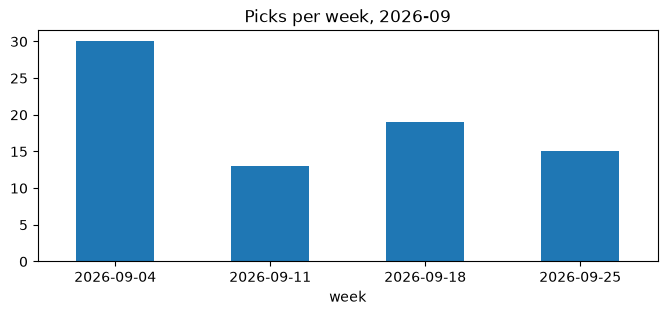

In [3]:
weekly = df.groupby("week").agg(releases=("name", "size"), picks=("is_pick", "sum"))
weekly["pick_rate_%"] = (weekly["picks"] / weekly["releases"] * 100).round(1)
display(weekly)
weekly["picks"].plot.bar(figsize=(8, 3), title=f"Picks per week, {MONTH}")
plt.xticks(rotation=0); plt.show()

## Genres among the picks

Count of picks per genre, next to the genre's share of all releases that month.

,picks,releases,pick_rate_%
genres,,,
Progressive Rock,19,39,48.7
Psychedelic Rock,16,31,51.6
Space Rock,13,13,100.0
Instrumental,10,37,27.0
Post Punk,9,42,21.4
Krautrock,7,11,63.6
Post Metal,7,17,41.2
Electronica,7,19,36.8
Progressive Metal,7,21,33.3


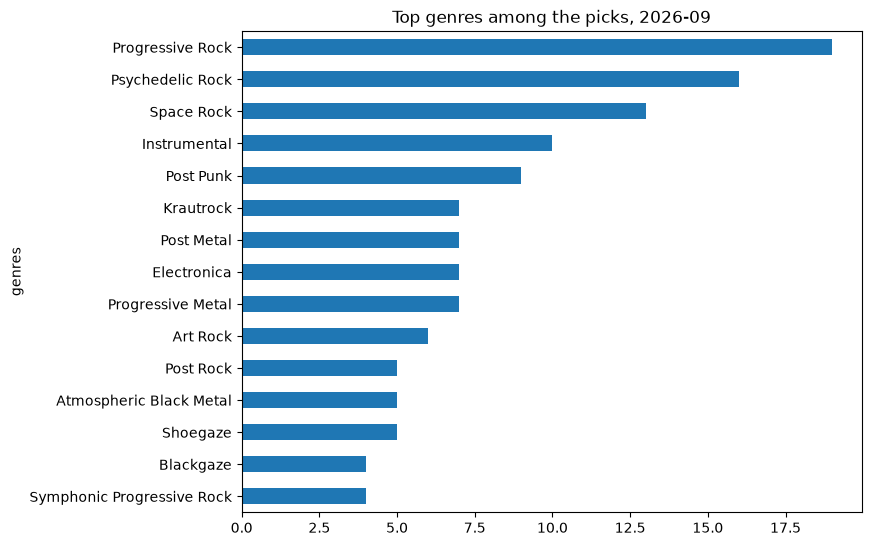

In [4]:
def genre_counts(frame):
    return frame.explode("genres")["genres"].dropna().value_counts()

all_g, pick_g = genre_counts(df), genre_counts(picks)
genres = pd.DataFrame({"picks": pick_g, "releases": all_g}).fillna(0).astype(int)
genres["pick_rate_%"] = (genres["picks"] / genres["releases"] * 100).round(1)
top = genres[genres["picks"] > 0].sort_values(["picks", "pick_rate_%"], ascending=False).head(TOP_N)
display(top)
top["picks"][::-1].plot.barh(figsize=(8, 0.35 * len(top) + 1), title=f"Top genres among the picks, {MONTH}")
plt.show()

## Hit rate by genre

Genres with at least 5 releases, ranked by how often they ended up as a pick.

In [5]:
display(genres[genres["releases"] >= 5].sort_values("pick_rate_%", ascending=False).head(TOP_N))

,picks,releases,pick_rate_%
genres,,,
Space Rock,13,13,100.0
Symphonic Progressive Rock,4,6,66.7
Blackgaze,4,6,66.7
Krautrock,7,11,63.6
Dark Folk,3,5,60.0
Psychedelic Rock,16,31,51.6
Avant-Garde Jazz,3,6,50.0
Trip Hop,4,8,50.0
Progressive Rock,19,39,48.7


## Artists and sections

In [6]:
display(picks.groupby("section").size().rename("picks"))
display(picks["artist"].value_counts().loc[lambda s: s > 1].rename("picks"))

section
Earlier    17
Friday     60
Name: picks, dtype: int64

Series([], Name: picks, dtype: int64)

# More information

## Releases per week

`Friday` is the release day of the post, `Earlier` is Saturday to Thursday before it.

section,Earlier,Friday,total
week,,,
2026-09-04,47,130,177
2026-09-11,38,103,141
2026-09-18,28,166,194
2026-09-25,37,206,243


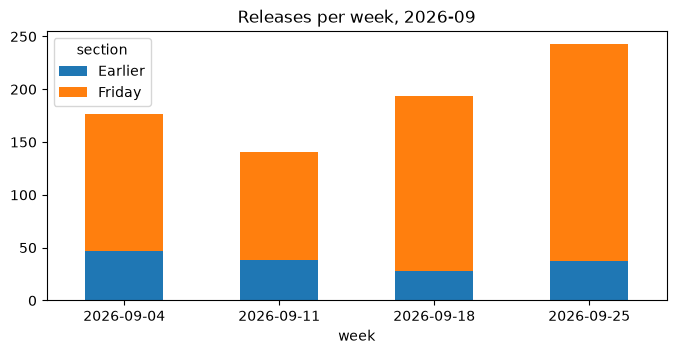

In [7]:
per_week = df.groupby(["week", "section"]).size().unstack(fill_value=0)
display(per_week.assign(total=per_week.sum(axis=1)))
per_week.plot.bar(stacked=True, figsize=(8, 3.5), title=f"Releases per week, {MONTH}")
plt.xticks(rotation=0); plt.show()

## Most common genres

genres
Indie Rock          66
Alternative Rock    57
Punk Rock           52
Black Metal         45
Post Punk           42
Progressive Rock    39
Indie Pop           38
Post Hardcore       37
Instrumental        37
Death Metal         37
Hard Rock           32
Doom Metal          32
Psychedelic Rock    31
Thrash Metal        31
Shoegaze            30
Name: releases, dtype: int64

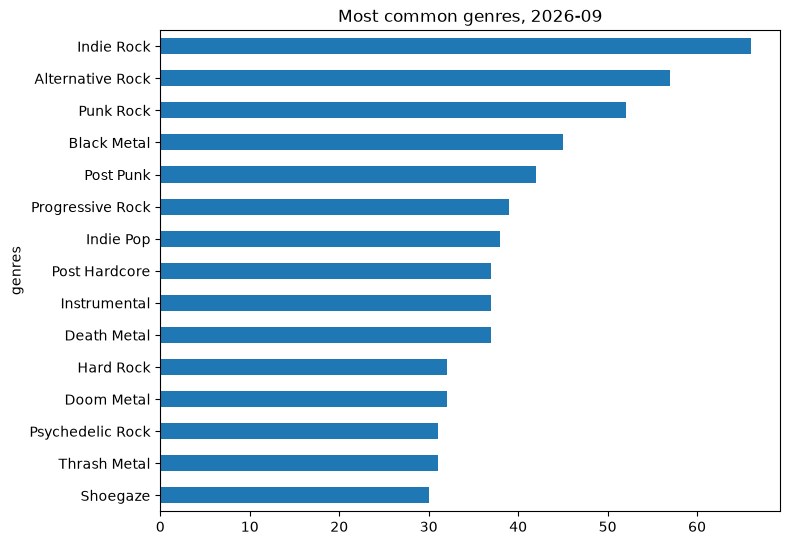

In [8]:
common = genre_counts(df).head(TOP_N)
display(common.rename("releases"))
common[::-1].plot.barh(figsize=(8, 0.35 * len(common) + 1), title=f"Most common genres, {MONTH}")
plt.show()

## Genre variety

How many different genres appeared, and how many tags a release carries on average.

In [9]:
tags = df["genres"].str.len()
print(f"{genre_counts(df).size} different genres, {tags.mean():.1f} tags per release on average")
display(tags.value_counts().sort_index().rename("releases").rename_axis("tags per release"))

296 different genres, 2.7 tags per release on average


tags per release
1    119
2    245
3    189
4    185
5     17
Name: releases, dtype: int64

## New genres this month

Genres that appear in this month but in no earlier post.

In [10]:
earlier = set(everything[everything["month"] < MONTH].explode("genres")["genres"].dropna())
new = genre_counts(df)[lambda s: ~s.index.isin(earlier)]
display(new.rename("releases"))

genres
AOR                    7
Death Rock             4
Pub Rock               2
Oi                     2
Deutschpop             2
Mod Revival            2
Folk Jazz              2
Ethereal Wave          2
Electronic Rock        1
Finnish Rock           1
Thrashcore             1
Outsider Music         1
Rock Opera             1
Avant-Garde Hip Hop    1
Japanese Folk          1
Jazz Pop               1
Gothic Folk            1
Dream Pop              1
Emoviolence            1
Name: releases, dtype: int64

## Typical genre combinations

Pairs of genres that show up together on the same release.

In [11]:
pairs = pd.Series(
    [" + ".join(sorted(p)) for g in df["genres"] for p in itertools.combinations(set(g), 2)]
).value_counts().head(TOP_N)
display(pairs.rename("releases"))

Alternative Rock + Indie Rock                 18
Death Metal + Old School Death Metal          11
Post Hardcore + Punk Rock                     10
Art Rock + Progressive Rock                   10
Doom Metal + Sludge Metal                     10
Instrumental + Progressive Rock                9
Psychedelic Rock + Space Rock                  9
Indie Rock + Post Punk                         9
Noise Rock + Post Hardcore                     9
Atmospheric Black Metal + Black Metal          9
Dreampop + Shoegaze                            9
Ambient + Instrumental                         9
Alternative Rock + Post Punk                   9
Hardcore Punk + Punk Rock                      8
Atmospheric Black Metal + Post Black Metal     8
Name: releases, dtype: int64

## Compared with the other months

Releases, picks and pick rate per month over everything the repo has.

In [16]:
by_month = everything.groupby("month").agg(releases=("name", "size"), picks=("is_pick", "sum"))
by_month["pick_rate_%"] = (by_month["picks"] / by_month["releases"] * 100).round(1)
display(by_month)

,releases,picks,pick_rate_%
month,,,
2024-11,1126,0,0.0
2024-12,484,0,0.0
2025-01,725,0,0.0
2025-02,825,0,0.0
2025-03,967,0,0.0
2025-04,915,4,0.4
2025-05,1410,18,1.3
2025-06,1120,12,1.1
2025-07,696,11,1.6


## Artists with several releases

In [17]:
display(df["artist"].value_counts().loc[lambda s: s > 1].rename("releases"))

artist
Horizon Ablaze       2
Storefront Church    2
Faust                2
Name: releases, dtype: int64